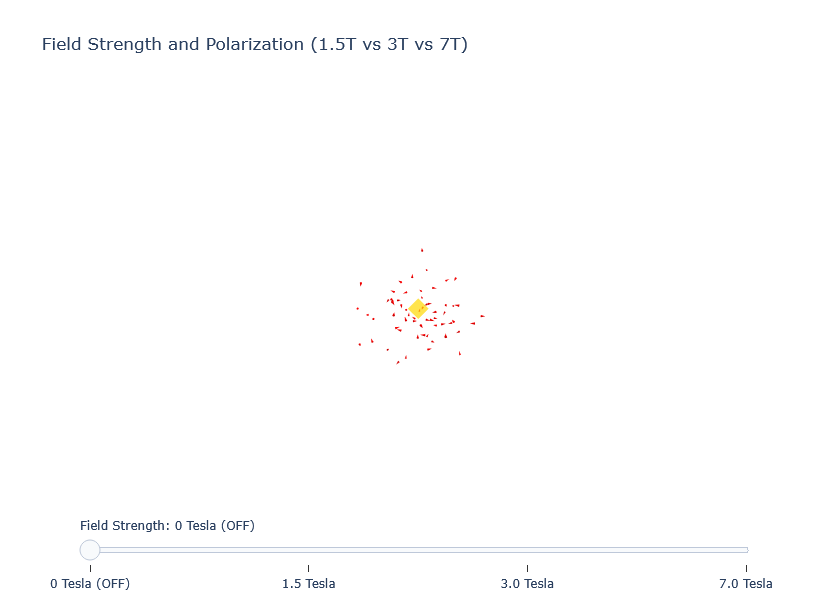

In [6]:
#| label: fig2

import numpy as np
import plotly.graph_objects as go

# 1. Setup
n_spins = 60
np.random.seed(42)

# Random positions for the protons in a 3D sphere
phi_pos = np.random.uniform(0, 2*np.pi, n_spins)
costheta_pos = np.random.uniform(-1, 1, n_spins)
theta_pos = np.arccos(costheta_pos)
r = np.random.uniform(0.3, 1.2, n_spins)

x_pos = r * np.sin(theta_pos) * np.cos(phi_pos)
y_pos = r * np.sin(theta_pos) * np.sin(phi_pos)
z_pos = r * np.cos(theta_pos)

# 2. Consistent Flip Thresholds and Wobble
flip_thresholds = np.random.uniform(0, 1, n_spins)
u_wobble = np.random.uniform(-0.25, 0.25, n_spins)
v_wobble = np.random.uniform(-0.25, 0.25, n_spins)

# 3. Define B0 states and corresponding "Up" ratios
b0_states = [0.0, 1.5, 3.0, 7.0]
up_ratios = {0.0: 0.5, 1.5: 0.65, 3.0: 0.85, 7.0: 0.98}

frames = []
steps = []

for b0 in b0_states:
    ratio = up_ratios[b0]
    
    if b0 == 0.0:
        u = np.random.uniform(-1, 1, n_spins)
        v = np.random.uniform(-1, 1, n_spins)
        w = np.random.uniform(-1, 1, n_spins)
        net_z = 0.0
        state_label = "0 Tesla (OFF)"
    else:
        w = np.where(flip_thresholds < ratio, 1.0, -1.0)
        u = u_wobble.copy()
        v = v_wobble.copy()
        
        # Calculate actual net vector, scaled for high visual impact
        net_z = (np.sum(w) / n_spins) * 2.8 
        state_label = f"{b0} Tesla"
        
    norms = np.sqrt(u**2 + v**2 + w**2)
    u, v, w = u/norms, v/norms, w/norms
        
    # Trace for individual protons
    protons = go.Cone(
        x=x_pos, y=y_pos, z=z_pos,
        u=u, v=v, w=w,
        sizemode="absolute", sizeref=0.25, 
        colorscale=[[0, 'blue'], [0.5, 'gray'], [1, 'red']], 
        cmin=-1, cmax=1,
        showscale=False,
        name="Individual Protons"
    )
    
    # Trace for Net Magnetization (Solid 3D Line with Diamond tip)
    net_vector = go.Scatter3d(
        x=[0, 0], y=[0, 0], z=[0, net_z],
        mode='lines+markers',
        line=dict(color='gold', width=15),
        marker=dict(size=[0, 15], color='gold', symbol='diamond'),
        name="Net Magnetization"
    )
    
    frames.append(go.Frame(data=[protons, net_vector], name=state_label))
    
    steps.append(dict(
        method="animate",
        args=[[state_label], {"mode": "immediate", "frame": {"duration": 800, "redraw": True}, "transition": {"duration": 500}}],
        label=state_label
    ))

# 4. Layout
fig = go.Figure(data=frames[0].data, frames=frames)

# CRITICAL FIX: Lock the axis ranges to prevent auto-zooming
fig.update_layout(
    scene=dict(
        xaxis=dict(visible=False, range=[-1.5, 1.5]),
        yaxis=dict(visible=False, range=[-1.5, 1.5]),
        zaxis=dict(visible=False, range=[-1.5, 3.0]),
        aspectmode='cube'
    ),
    sliders=[dict(active=0, currentvalue={"prefix": "Field Strength: "}, pad={"t": 50}, steps=steps)],
    height=600,
    title="Field Strength and Polarization (1.5T vs 3T vs 7T)"
)

fig